### import necessary libraries

In [2]:
import numpy as np
from scipy.spatial.distance import cdist

In [3]:
# -----------------------------
# Feasible lattice construction
# -----------------------------
def build_feasible_lattice(total_ml=8.0, step_ml=0.1):
    """
    Generate all feasible (Co, MIM, TEA) on a lattice with:
    - Co > 0, MIM > 0, TEA >= 0
    - Co + MIM + TEA = total_ml
    - each component is a multiple of step_ml
    Returns an array of shape (N, 3) in mL.
    """
    units = int(round(total_ml / step_ml))
    pts = []
    # a, b, c are lattice units for Co, MIM, TEA respectively
    for a in range(1, units):             # Co units > 0
        for b in range(1, units - a + 1):     # MIM units > 0
            c = units - a - b             # TEA units >= 0
            if c < 0:
                continue
            pts.append((a, b, c))
    pts = np.array(pts, dtype=float) * step_ml
    return pts

In [4]:
# -----------------------------
# Greedy maximin on scaled simplex
# -----------------------------
def maximin_scaled(grid_ml, n_samples=20, random_state=111):
    """
    Greedy farthest-point (maximin) selection on a simplex:
    - Work in composition space by dividing by the total volume (sum=1).
    - Start from a reproducible random feasible point.
    Returns indices of selected points.
    """
    rng = np.random.default_rng(random_state)
    total_ml = np.sum(grid_ml[0])              # constant = 8.0
    grid_scaled = grid_ml / total_ml           # to compositions in [0,1], sum=1

    selected_idx = [rng.integers(0, len(grid_scaled))]
    selected_pts = [grid_scaled[selected_idx[0]]]

    for _ in range(n_samples - 1):
        dists = cdist(grid_scaled, np.array(selected_pts))
        min_d = np.min(dists, axis=1)
        next_idx = int(np.argmax(min_d))
        selected_idx.append(next_idx)
        selected_pts.append(grid_scaled[next_idx])
    return np.array(selected_idx)

In [5]:
def initial_sampling(n_init=20, total_ml=8.0, step_ml=0.1, random_state=111):
    """
    Produce n_init initial samples satisfying:
    - Co > 0, MIM > 0, TEA >= 0
    - sum = total_ml, step = step_ml
    - No TEA cap, no duplication
    Returns an array (n_init, 3) in mL.
    """
    grid_pts = build_feasible_lattice(total_ml=total_ml, step_ml=step_ml)
    idx = maximin_scaled(grid_pts, n_samples=n_init, random_state=random_state)
    return grid_pts[idx]

In [6]:
# pip install python-ternary matplotlib numpy
import matplotlib.pyplot as plt
import ternary

def plot_sampling_space(scale=8):
    """
    Plot the ternary sampling space for (Co2+, 2-mIm, TEA) volumes.
    Co2+ + 2-mIm + TEA = scale (mL), step = 0.1 mL implicitly via grid resolution.
    
    Returns
    -------
    tax : ternary.TernaryAxesSubplot
        Ternary axis handle for adding scatter points later.
    """
    # Build lattice points (0.1 mL resolution → scale*10 discrete levels)
    points = []
    for a in range(0, scale*10 + 1):
        for b in range(0, scale*10 - a + 1):
            c = scale*10 - a - b
            points.append((a/10, b/10, c/10))

    # Set up ternary plot
    fig, tax = ternary.figure(scale=scale)
    tax.gridlines(multiple=1, color="0.8", linewidth=0.8, zorder=0)
    tax.boundary(linewidth=2.0, zorder=0)

    # Axis labels
    # tax.left_corner_label(r"Co$^{2+}$ (mL)", fontsize=14, offset=0.4)
    # Remove left corner label
    tax.left_corner_label("", offset=0)

    # Add a manually positioned label (Co²⁺)
    tax.annotate(
        r"Co$^{2+}$ (mL)",
        position=(0, 1, 0),            # bottom-left vertex (Co2+=0, 2-mIm=8, TEA=0)
        fontsize=14,
        textcoords="offset points",
        xytext=(-35,-60),
        ha='center', va='center'
    )

    # tax.right_corner_label("2-mIm (mL)", fontsize=14, offset=0.4)
    tax.right_corner_label("", offset=0)
    tax.annotate(
        r"2-mIm (mL)",
        position=(0, 1, 0),
        fontsize=14,
        xytext=(315, -60),
        textcoords="offset points",
        ha='center', va='center'
    )

    tax.top_corner_label("TEA (mL)", fontsize=14, offset=0.2)

    # Ticks
    tax.ticks(
    axis='lbr', 
    multiple=1, 
    linewidth=1, 
    tick_formats="%d", 
    fontsize=12,
    offset=0.015  
    )

    # Formatting
    tax.clear_matplotlib_ticks()
    tax.get_axes().axis('off')
    plt.tight_layout()
    
    return tax


def plot_initial_samples_on_ternary(tax, samples, marker_size=60, marker_color="red"):
    """
    Add initial sampling points to the existing ternary plot.
    
    """
    # Convert (Co, MIM, TEA) to ternary coordinates (left, right, top)
    ternary_pts = [(row[1], row[2], row[0]) for row in samples]

    # Plot points as open circles
    for p in ternary_pts:
        tax.scatter([p], marker='o', color=marker_color,
                    s=marker_size, edgecolors=marker_color, facecolors='none')





c:\Users\yezuy\miniconda3\Lib\site-packages\ternary\plotting.py:148: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(xs, ys, vmin=vmin, vmax=vmax, **kwargs)


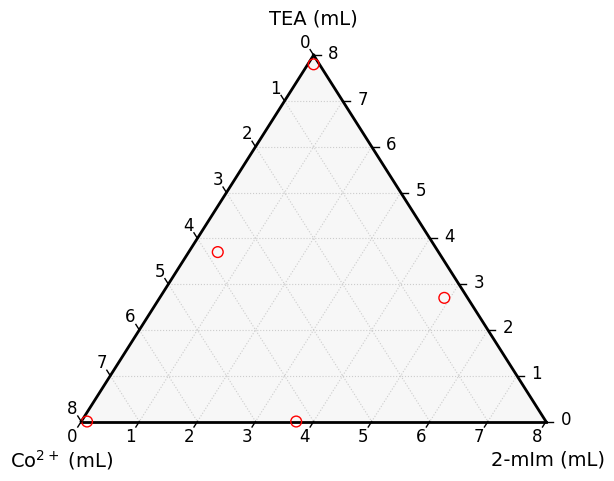

[[0.4 4.9 2.7]
 [7.9 0.1 0. ]
 [0.1 0.1 7.8]
 [3.8 0.5 3.7]
 [4.3 3.7 0. ]]


In [7]:
tax = plot_sampling_space()         # draw feasible grid / triangle
samples = initial_sampling(n_init=5, total_ml=8.0, step_ml=0.1, random_state=42)
plot_initial_samples_on_ternary(tax, samples)
plt.show()
print(samples)

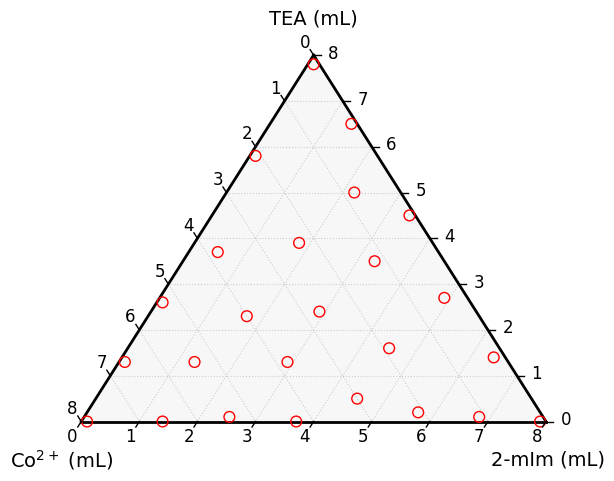

[[0.4 4.9 2.7]
 [7.9 0.1 0. ]
 [0.1 0.1 7.8]
 [3.8 0.5 3.7]
 [4.3 3.7 0. ]
 [0.1 7.9 0. ]
 [0.8 2.2 5. ]
 [2.1 5.7 0.2]
 [5.4 1.3 1.3]
 [2.7 2.9 2.4]
 [2.1 0.1 5.8]
 [0.2 6.4 1.4]
 [2.3 1.8 3.9]
 [1.2 3.3 3.5]
 [1.9 4.5 1.6]
 [0.1 1.4 6.5]
 [6.6 1.4 0. ]
 [5.3 0.1 2.6]
 [4.  1.7 2.3]
 [6.6 0.1 1.3]
 [5.4 2.5 0.1]
 [3.8 2.9 1.3]
 [3.  4.5 0.5]
 [1.1 6.8 0.1]
 [0.1 3.4 4.5]]


In [27]:
tax = plot_sampling_space()         # draw feasible grid / triangle
samples = initial_sampling(n_init=25, total_ml=8.0, step_ml=0.1, random_state=42)
plot_initial_samples_on_ternary(tax, samples)
plt.show()
print(samples)

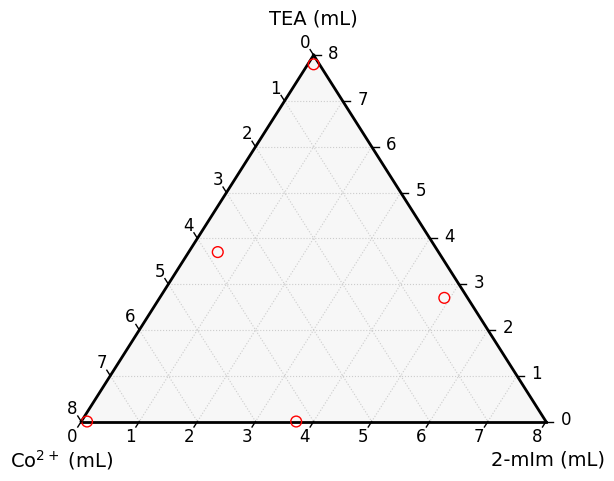

[[0.4 4.9 2.7]
 [7.9 0.1 0. ]
 [0.1 0.1 7.8]
 [3.8 0.5 3.7]
 [4.3 3.7 0. ]]


In [31]:
tax = plot_sampling_space()         # draw feasible grid / triangle
samples = initial_sampling(n_init=5, total_ml=8.0, step_ml=0.1, random_state=42)
plot_initial_samples_on_ternary(tax, samples)
plt.show()
print(samples)

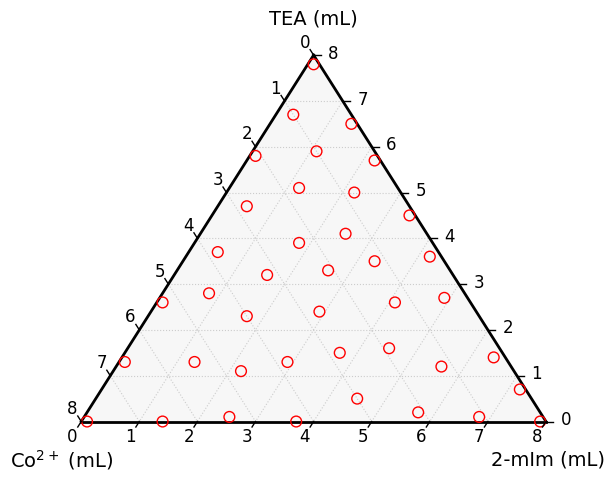

[[0.4 4.9 2.7]
 [7.9 0.1 0. ]
 [0.1 0.1 7.8]
 [3.8 0.5 3.7]
 [4.3 3.7 0. ]
 [0.1 7.9 0. ]
 [0.8 2.2 5. ]
 [2.1 5.7 0.2]
 [5.4 1.3 1.3]
 [2.7 2.9 2.4]
 [2.1 0.1 5.8]
 [0.2 6.4 1.4]
 [2.3 1.8 3.9]
 [1.2 3.3 3.5]
 [1.9 4.5 1.6]
 [0.1 1.4 6.5]
 [6.6 1.4 0. ]
 [5.3 0.1 2.6]
 [4.  1.7 2.3]
 [6.6 0.1 1.3]
 [5.4 2.5 0.1]
 [3.8 2.9 1.3]
 [3.  4.5 0.5]
 [1.1 6.8 0.1]
 [0.1 3.4 4.5]
 [1.  0.3 6.7]
 [2.8 0.5 4.7]
 [1.7 1.2 5.1]
 [1.2 5.6 1.2]
 [2.8 3.7 1.5]
 [1.3 4.1 2.6]
 [0.2 4.2 3.6]
 [3.2 1.6 3.2]
 [4.7 2.2 1.1]
 [4.4 0.8 2.8]
 [1.  1.1 5.9]
 [1.4 2.5 4.1]
 [2.1 2.6 3.3]
 [0.1 2.2 5.7]
 [0.1 7.2 0.7]]


In [48]:
tax = plot_sampling_space()         # draw feasible grid / triangle
samples = initial_sampling(n_init=40, total_ml=8.0, step_ml=0.1, random_state=42)
plot_initial_samples_on_ternary(tax, samples)
plt.show()
print(samples)

In [9]:
def random_sampling(grid_ml, n_samples=5, random_state=42):
    """
    Uniform random sampling without replacement on the feasible lattice.
    - grid_ml: feasible lattice points in mL.
    - n_samples: number of random samples to draw.
    - random_state: seed for reproducibility.
    Returns an array (n_samples, 3) in mL.
    """
    rng = np.random.default_rng(random_state)
    idx = rng.choice(len(grid_ml), size=n_samples, replace=False)
    return grid_ml[idx]


In [15]:
grid_pts = build_feasible_lattice(total_ml=8.0, step_ml=0.1)
rand_samples = random_sampling(grid_pts, n_samples=25, random_state=42)
print(rand_samples)

[[3.6 2.2 2.2]
 [1.7 2.7 3.6]
 [0.9 3.  4.1]
 [4.3 1.3 2.4]
 [0.8 4.5 2.7]
 [4.3 2.  1.7]
 [3.3 2.3 2.4]
 [5.  0.2 2.8]
 [4.1 1.7 2.2]
 [0.6 1.9 5.5]
 [0.4 3.7 3.9]
 [2.  4.8 1.2]
 [2.5 3.7 1.8]
 [3.9 1.8 2.3]
 [0.4 4.6 3. ]
 [3.8 0.4 3.8]
 [2.1 3.1 2.8]
 [4.2 0.9 2.9]
 [2.  3.  3. ]
 [2.4 1.6 4. ]
 [5.8 2.1 0.1]
 [6.7 0.2 1.1]
 [4.8 1.7 1.5]
 [0.4 6.3 1.3]
 [2.4 5.4 0.2]]


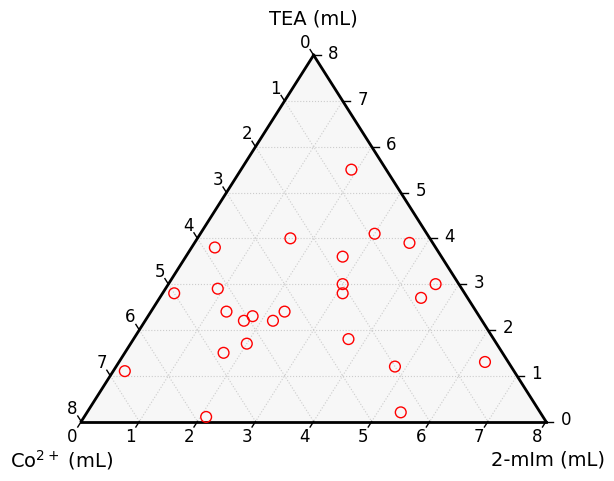

In [16]:
tax = plot_sampling_space()         # draw feasible grid / triangle
#samples = initial_sampling(n_init=25, total_ml=8.0, step_ml=0.1, random_state=42)
plot_initial_samples_on_ternary(tax, rand_samples)
plt.show()